In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyranges as pr
import seaborn as sb
import sys
from scipy.stats import pearsonr
import math
from scipy.stats import norm, fisher_exact

# custom
sys.path.insert(0, "..")
from analysis_utils import *


In [2]:
def get_base_composition(motif):
    return ''.join(sorted(set(motif)))
def calculate_odds_ratio_for_columns(column_values, all_data_outliers, LPS, confidence_level=0.95):
    """
    Calculate the odds ratio, confidence interval, and Fisher's exact test for multiple columns and their corresponding values.

    Args:
        column_values (dict): A dictionary where keys are column names and values are the corresponding values to filter by.
        all_data_outliers (pd.DataFrame): DataFrame containing outlier data.
        LPS (pd.DataFrame): DataFrame containing the overall dataset.
        confidence_level (float): Confidence level for the confidence interval (default: 0.95 for 95% CI).

    Returns:
        tuple: Odds ratio, p-value from Fisher's exact test, lower CI bound, upper CI bound.
    """

    
    # Filter the data based on the column-value pairs
    outliers_filtered = all_data_outliers
    overall_filtered = LPS
    for column, value in column_values.items():
        outliers_filtered = outliers_filtered[outliers_filtered[column] == value]
        overall_filtered = overall_filtered[overall_filtered[column] == value]

    # number of outliers in the group
    a = outliers_filtered.shape[0]
    # number of non-outliers in the group
    b = overall_filtered.shape[0] - a
    # number of outliers not in the group
    c = all_data_outliers.shape[0] - a
    # number of non-outliers not in the group
    d = LPS.shape[0] - overall_filtered.shape[0] - c

    # Fisher's exact test
    odds_ratio, p_value = fisher_exact([[a, b], [c, d]])

    # Calculate confidence interval for odds ratio
    if a > 0 and b > 0 and c > 0 and d > 0:
        # Log odds ratio and its standard error
        log_or = math.log(odds_ratio)
        se_log_or = math.sqrt(1/a + 1/b + 1/c + 1/d)
        
        # Critical value for the given confidence level
        alpha = 1 - confidence_level
        z_critical = norm.ppf(1 - alpha/2)
        
        # Confidence interval for log odds ratio
        ci_lower_log = log_or - z_critical * se_log_or
        ci_upper_log = log_or + z_critical * se_log_or
        
        # Transform back to odds ratio scale
        ci_lower = math.exp(ci_lower_log)
        ci_upper = math.exp(ci_upper_log)
    else:
        # print the contingency table values for debugging
        # print(f"Contingency table values: a={a}, b={b}, c={c}, d={d}")
        # Handle cases with zero counts
        ci_lower = 0
        ci_upper = float('inf')

    return odds_ratio, p_value, ci_lower, ci_upper
# Bonferroni correction helper
def bonferroni_correction(pvals):
    n = len(pvals)
    if n == 0:
        return []
    return [min(p * n, 1.0) for p in pvals]

# Figure7A-D:Alu Outlier Analysis

In [ ]:
plot_dir = "/home/kvandeyn/MEI_STR/scripts/notebooks/MEI_STR/manuscript_figures/figure_7_manuscript"
title_size=7
label_size=6
tick_size=5

In [ ]:
# read in data
LPS = pd.read_csv("../feature_generation_scripts/LPS_metrics_with_annotations.tsv.gz", compression="gzip", sep="\t")

# add columns for plotting
major_families = ["non_mei", "Retroposon_SVA", "LINE_L1", "LINE_L2", "SINE_Alu"]
mei_family_order = ["non-TE","Alu","LINE1","LINE2","SVA"]
relative_pos_order =["non-TE","5'","internal","3'"]
# add a plotting value for the major families names
LPS["mei_family_plot"] = LPS["mei_family"].replace({
    "non_mei": "non-TE",
    "Retroposon_SVA": "SVA",
    "LINE_L1": "LINE1",
    "LINE_L2": "LINE2",
    "SINE_Alu": "Alu"
})
LPS["relative_pos_plot"] = LPS["terminal_label"].replace({
    "5'terminal": "5'",
    "3'terminal": "3'",
    "internal": "internal",
    "non_mei": "non-TE"
})

# get variable/polymorphic regions labled
LPS["variable"] = LPS["Stdev"] > 0
# update XDP locus since it is split across 2 which messes with its plotting
LPS.loc[LPS.LocusID.isin([4383298.0, 4383299.0]), ['disease_id', 'disease_associated', 'terminal_label']] = ['XDP', True, "5'terminal"]

# get detected_period as the period of the lps motif
LPS["detected_period"] = LPS["most_common_motif"].str.len()
#get base composition from the simple_motif based on the most common motif
LPS["simple_motif"] = LPS["most_common_motif"].apply(SequenceAttributes.get_simple_motif)
LPS["base_composition"] = LPS["simple_motif"].apply(get_base_composition).apply(SequenceAttributes.get_simple_motif)

alu_labels = pd.read_csv("combined_alu_strs_for_divergence_analysis_manuscript.tsv", sep="\t")

# combine LPS data with alu labels so we can do poly(A) analysis
alu_LPS = alu_labels.merge(LPS[["LocusID","Mean","Stdev","unique_lps","base_composition","detected_period","num_total_lps_motifs","disease_associated","GencodeGeneRegion"]], on="LocusID", how="left").dropna(subset=["Mean"])
alu_LPS

/tmp/ipykernel_3225616/4233851275.py:36: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  alu_labels = pd.read_csv("/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/alu_lineage_data/alu_sets/combined_alu_strs_for_divergence_analysis.tsv", sep="\t")


,chrom,start,end,LocusID,start_mei,end_mei,mei_id,mei_subfamily,orientation,consensus_relative_start,...,divergence,label,Mean,Stdev,unique_lps,base_composition,detected_period,num_total_lps_motifs,disease_associated,GencodeGeneRegion
0,chr8,735310.0,735365.0,2083543.0,735178,735310,AluSc5.chr8:735178-735310,AluSc5,+,139.0,...,9.6,Other,29.181818,4.133998,7.0,AT,3.0,1.0,False,intergenic
1,chr20,737623.0,737660.0,4050606.0,737494,737624,AluSq2.chr20:737494-737624,AluSq2,+,133.0,...,10.0,Alinker,38.892857,5.101395,7.0,AT,3.0,1.0,False,intergenic
2,chr9,948902.0,948945.0,2300668.0,948779,948903,AluSx1.chr9:948779-948903,AluSx1,+,133.0,...,14.6,Alinker,40.005076,3.458965,6.0,AT,3.0,1.0,False,intron
3,chr19,1191065.0,1191093.0,3934403.0,1190941,1191057,AluSx1.chr19:1190941-1191057,AluSx1,+,133.0,...,14.9,Alinker,25.000000,0.000000,1.0,AT,5.0,1.0,False,intron
4,chr1,1653824.0,1653863.0,2476.0,1653702,1653825,AluSx.chr1:1653702-1653825,AluSx,+,126.0,...,14.8,Alinker,41.673684,5.342860,14.0,AC,2.0,1.0,False,intron
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401147,chrX,154792476.0,154792485.0,4502478.0,154792467,154792506,AluSx3.chrX:154792467-154792506,AluSx3,+,146.0,...,17.5,Other,9.000000,0.000000,1.0,AC,3.0,1.0,False,intron
401148,chrX,154833485.0,154833494.0,4502528.0,154833343,154833607,AluJo.chrX:154833343-154833607,AluJo,+,146.0,...,12.1,Other,9.000000,0.000000,1.0,AC,3.0,1.0,False,intron
401149,chrX,155225341.0,155225350.0,4503033.0,155225247,155225499,AluSx.chrX:155225247-155225499,AluSx,-,146.0,...,11.1,Other,8.880795,0.762769,3.0,AC,3.0,1.0,False,intron
401150,chrX,155287323.0,155287342.0,4503120.0,155287322,155287615,AluSx.chrX:155287322-155287615,AluSx,-,305.0,...,13.3,Poly(A),16.027027,0.327685,2.0,AG,4.0,1.0,False,intron


## Get outliers with respect to only Alu poly(A)-tail STRs

In [6]:
polya = alu_LPS[(alu_LPS.label == "Poly(A)")]
# drop rows where no Mean
polya = polya[~polya.Mean.isna()]
polya

,chrom,start,end,LocusID,start_mei,end_mei,mei_id,mei_subfamily,orientation,consensus_relative_start,...,divergence,label,Mean,Stdev,unique_lps,base_composition,detected_period,num_total_lps_motifs,disease_associated,GencodeGeneRegion
7,chr12,1989345.0,1989376.0,2901826.0,1989103,1989341,AluJr4.chr12:1989103-1989341,AluJr4,+,305.0,...,19.2,Poly(A),30.000000,0.000000,1.0,ACG,6.0,1.0,False,intron
11,chr4,2149295.0,2149324.0,1031505.0,2149035,2149296,AluSq2.chr4:2149035-2149296,AluSq2,+,298.0,...,14.8,Poly(A),25.246231,1.895425,3.0,AC,4.0,1.0,False,intron
20,chr10,3168914.0,3168965.0,2491515.0,3168427,3168478,AluJo.chr10:3168427-3168478,AluJo,+,503.0,...,14.9,Poly(A),30.694301,15.874992,15.0,AC,2.0,1.0,False,intron
34,chr19,4779522.0,4779551.0,3942927.0,4779320,4779523,AluJb.chr19:4779320-4779523,AluJb,+,298.0,...,14.8,Poly(A),38.644809,6.376148,5.0,AT,4.0,1.0,False,intergenic
58,chr21,8227977.0,8228022.0,4153387.0,8227728,8227956,AluSx1.chr21:8227728-8227956,AluSx1,+,325.0,...,14.2,Poly(A),42.460000,3.166765,6.0,ACT,4.0,1.0,False,intergenic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
401143,chrX,154223799.0,154223811.0,4501548.0,154223501,154223810,AluJr.chrX:154223501-154223810,AluJr,+,314.0,...,14.2,Poly(A),12.000000,0.000000,1.0,AG,4.0,1.0,False,intron
401145,chrX,154303177.0,154303225.0,4501706.0,154303178,154303379,AluJb.chrX:154303178-154303379,AluJb,-,300.0,...,17.3,Poly(A),43.613793,4.681860,7.0,AT,4.0,1.0,False,intron
401146,chrX,154603140.0,154603168.0,4502226.0,154603171,154603449,AluJr.chrX:154603171-154603449,AluJr,-,309.0,...,14.7,Poly(A),31.753425,2.487122,5.0,AT,4.0,1.0,False,intergenic
401150,chrX,155287323.0,155287342.0,4503120.0,155287322,155287615,AluSx.chrX:155287322-155287615,AluSx,-,305.0,...,13.3,Poly(A),16.027027,0.327685,2.0,AG,4.0,1.0,False,intron


In [7]:
# get outliers from the overall set so we can assess sequence polymorphism in outliers vs overall
polya_variable = polya[(polya.unique_lps > 1)& (polya.detected_period >2) & (polya.detected_period <=6)]
polya_3_to_6 = polya[(polya.detected_period >2) & (polya.detected_period <=6)]
# Identify outlier loci
# Get rows in the top 95th percentile of unique_lps
unique_lps_95 = polya_variable['unique_lps'].quantile(0.95)
print(f"95th percentile threshold for unique_lps: {unique_lps_95}")

# Get all rows that are in the top 80th percentile (>= 80th percentile)
top_95th_percentile_rows = polya_variable[polya_variable['unique_lps'] >= unique_lps_95]
print(f"Number of rows in top 95th percentile: {len(top_95th_percentile_rows)}")
print(f"Percentage of total rows: {len(top_95th_percentile_rows) / len(polya[polya.detected_period > 2]) * 100:.1f}%")
print(f"Percentage of variable rows: {len(top_95th_percentile_rows) / len(polya_variable) * 100:.1f}%")

# Display some basic statistics
print(f"\nUnique_lps statistics for top 95th percentile:")
print(f"Min: {top_95th_percentile_rows['unique_lps'].min()}")
print(f"Max: {top_95th_percentile_rows['unique_lps'].max()}")
print(f"Mean: {top_95th_percentile_rows['unique_lps'].mean():.2f}")

# print the number of disease_associated regions and which ones are in this set
print(f"\nNumber of disease associated regions in top 95th percentile: {top_95th_percentile_rows[top_95th_percentile_rows['disease_associated']].shape[0]}")
print(f"Percentage of disease associated regions in top 95th percentile: {top_95th_percentile_rows[top_95th_percentile_rows['disease_associated']].shape[0] / polya_3_to_6[polya_3_to_6['disease_associated']].shape[0] * 100:.1f}%")

# Get the rows in the top 90th percentile of Mean
mean_threshold = polya_variable['Mean'].quantile(0.90)
Mean_outliers = polya_variable[polya_variable['Mean'] > mean_threshold]

# print the summary
print(f"Number of rows in Mean outliers: {len(Mean_outliers)}")
print(f"Percentage of total rows: {len(Mean_outliers) / len(polya_3_to_6) * 100:.1f}%")
print(f"Percentage of variable rows: {len(Mean_outliers) / len(polya_variable) * 100:.1f}%")

print(f"\nMean statistics for Mean outliers:")
print(f"Min: {Mean_outliers['Mean'].min()}")
print(f"Max: {Mean_outliers['Mean'].max()}")
print(f"Mean: {Mean_outliers['Mean'].mean():.2f}")

# print the number of disease_associated regions and which ones are in this set
print(f"\nNumber of disease associated regions in Mean outliers: {Mean_outliers[Mean_outliers['disease_associated']].shape[0]}")
print(f"Percentage of disease associated regions in Mean outliers: {Mean_outliers[Mean_outliers['disease_associated']].shape[0] / polya_3_to_6[polya_3_to_6['disease_associated']].shape[0] * 100:.1f}%")

# Get the 95th percentile of Stdev
std_threshold = polya_variable['Stdev'].quantile(0.95)
Stdev_outliers = polya_variable[polya_variable['Stdev'] > std_threshold]

# print the summary
print(f"Number of rows in Stdev outliers: {len(Stdev_outliers)}")
print(f"Percentage of total rows: {len(Stdev_outliers) / len(polya_3_to_6) * 100:.1f}%")
print(f"Percentage of variable rows: {len(Stdev_outliers) / len(polya_variable) * 100:.1f}%")

print(f"Percentage of variable rows: {len(Stdev_outliers) / len(polya_variable) * 100:.1f}%")

print(f"\nMean statistics for Stdev outliers:")
print(f"Min: {Stdev_outliers['Stdev'].min()}")
print(f"Max: {Stdev_outliers['Stdev'].max()}")
print(f"Mean: {Stdev_outliers['Stdev'].mean():.2f}")

# print the number of disease_associated regions and which ones are in this set
print(f"\nNumber of disease associated regions in Stdev outliers: {Stdev_outliers[Stdev_outliers['disease_associated']].shape[0]}")
print(f"Percentage of disease associated regions in Stdev outliers: {Stdev_outliers[Stdev_outliers['disease_associated']].shape[0] / polya_3_to_6[polya_3_to_6['disease_associated']].shape[0] * 100:.1f}%")


95th percentile threshold for unique_lps: 8.0
Number of rows in top 95th percentile: 2938
Percentage of total rows: 1.6%
Percentage of variable rows: 5.1%

Unique_lps statistics for top 95th percentile:
Min: 8.0
Max: 46.0
Mean: 9.33

Number of disease associated regions in top 95th percentile: 8
Percentage of disease associated regions in top 95th percentile: 100.0%
Number of rows in Mean outliers: 5722
Percentage of total rows: 3.2%
Percentage of variable rows: 10.0%

Mean statistics for Mean outliers:
Min: 34.52307692307692
Max: 126.8627450980392
Mean: 41.90

Number of disease associated regions in Mean outliers: 8
Percentage of disease associated regions in Mean outliers: 100.0%
Number of rows in Stdev outliers: 2861
Percentage of total rows: 1.6%
Percentage of variable rows: 5.0%
Percentage of variable rows: 5.0%

Mean statistics for Stdev outliers:
Min: 6.079398138817548
Max: 367.6377669245515
Mean: 9.10

Number of disease associated regions in Stdev outliers: 8
Percentage of dise

In [8]:
# take the intersection of the three outlier sets to get the overall outliers
polya_outliers = set(Mean_outliers.index).intersection(set(Stdev_outliers.index)).intersection(set(top_95th_percentile_rows.index))
polya_outliers = polya_variable.loc[list(polya_outliers)]
print(f"Number of overall outliers: {len(polya_outliers)}")
print(f"Percentage of total rows: {len(polya_outliers) / len(alu_LPS) * 100:.1f}%")
print(f"Percentage of variable rows: {len(polya_outliers) / len(polya_variable) * 100:.1f}%")

# print the summary stats for each metric
# Mean
print()
print("Mean Mean LPS length in outliers: ", polya_outliers["Mean"].mean())
print("The Mean LPS length range in outliers was (", polya_outliers["Mean"].min(),",",polya_outliers["Mean"].max(),")")
print()
print("Mean Standard Deviation LPS length in outliers: ", polya_outliers["Stdev"].mean())
print("The Standard Deviation LPS length range in outliers was (", polya_outliers["Stdev"].min(),",",polya_outliers["Stdev"].max(),")")
print()
print("Mean number of unique LPS lengths in outliers: ", polya_outliers["unique_lps"].mean())
print("The number of unique LPS lengths range in outliers was (", polya_outliers["unique_lps"].min(),",",polya_outliers["unique_lps"].max(),")")
print()



# print the disease_associated regions disease_id that are in and not in the overall outliers
print(f"Total variable disease associated regions: {polya_variable[polya_variable['disease_associated']].shape[0]}")
# save the LocusIDs of the outliers
polya_outliers["LocusID"].to_csv("polya_outliers_locusids.txt", index=False)
# print(f"Disease associated regions in overall outliers: {polya_outliers[polya_outliers['disease_associated']].disease_id.tolist()}")
# print(f"Disease associated regions not in overall outliers: {polya_variable[~polya_variable.index.isin(polya_outliers.index) & polya_variable['disease_associated']]['disease_id'].tolist()}")


Number of overall outliers: 1254
Percentage of total rows: 0.3%
Percentage of variable rows: 2.2%

Mean Mean LPS length in outliers:  46.27131406526689
The Mean LPS length range in outliers was ( 34.54545454545455 , 126.8627450980392 )

Mean Standard Deviation LPS length in outliers:  10.650904626380981
The Standard Deviation LPS length range in outliers was ( 6.087964067088401 , 367.6377669245515 )

Mean number of unique LPS lengths in outliers:  10.185805422647528
The number of unique LPS lengths range in outliers was ( 8.0 , 46.0 )

Total variable disease associated regions: 8


In [9]:
polya_outliers

,chrom,start,end,LocusID,start_mei,end_mei,mei_id,mei_subfamily,orientation,consensus_relative_start,...,divergence,label,Mean,Stdev,unique_lps,base_composition,detected_period,num_total_lps_motifs,disease_associated,GencodeGeneRegion
90118,chr13,24406388.0,24406438.0,3123882.0,24406109,24406388,AluSq2.chr13:24406109-24406388,AluSq2,+,296.0,...,7.9,Poly(A),60.128205,13.982002,15.0,AT,5.0,1.0,False,intergenic
57352,chr11,24581670.0,24581730.0,2734464.0,24581389,24581669,AluSz.chr11:24581389-24581669,AluSz,+,296.0,...,17.1,Poly(A),46.793651,9.241313,8.0,AT,6.0,1.0,False,intron
335885,chr8,32582069.0,32582094.0,2132919.0,32582115,32582397,AluJb.chr8:32582115-32582397,AluJb,-,317.0,...,15.9,Poly(A),38.035714,13.743041,10.0,AT,5.0,1.0,False,intron
57369,chr11,24931209.0,24931269.0,2735040.0,24930932,24931209,AluSc.chr11:24930932-24931209,AluSc,+,296.0,...,10.4,Poly(A),50.838150,9.140353,8.0,AT,5.0,1.0,False,intron
81948,chr12,97835241.0,97835270.0,3049990.0,97835271,97835550,AluSg7.chr12:97835271-97835550,AluSg7,-,297.0,...,9.3,Poly(A),40.309645,10.012711,10.0,AC,3.0,1.0,False,intergenic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196583,chr2,104535699.0,104535741.0,523993.0,104535427,104535699,AluSx.chr2:104535427-104535699,AluSx,+,296.0,...,10.3,Poly(A),35.632653,10.852807,11.0,AT,3.0,1.0,False,intergenic
8168,chr1,20332479.0,20332549.0,35141.0,20332204,20332479,AluSx1.chr1:20332204-20332479,AluSx1,+,296.0,...,11.6,Poly(A),69.923469,11.978691,12.0,AT,5.0,1.0,False,intron
360433,chr9,126060249.0,126060285.0,2464695.0,126060288,126060569,AluSx3.chr9:126060288-126060569,AluSx3,-,300.0,...,9.2,Poly(A),37.195652,6.104594,8.0,AT,4.0,1.0,False,intron
16380,chr1,57060125.0,57060165.0,100643.0,57060126,57060449,AluSg.chr1:57060126-57060449,AluSg,-,299.0,...,7.8,Poly(A),47.329843,9.731532,8.0,AT,5.0,1.0,False,intron


## Poly(A) outlier enrichment testing

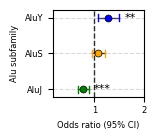

Subfamily Only ORs and p-values:
AluJ: OR=0.77, Significance=***, p-value=0.001
AluS: OR=1.08, Significance=, p-value=0.230
AluY: OR=1.27, Significance=**, p-value=0.007


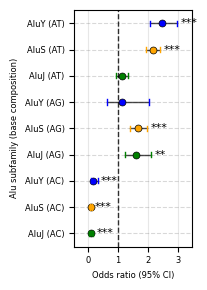

Subfamily Only ORs and p-values:
AluJ (AC): OR=0.10, Significance=***, p-value=0.000
AluS (AC): OR=0.10, Significance=***, p-value=0.000
AluY (AC): OR=0.18, Significance=***, p-value=0.000
AluJ (AG): OR=1.61, Significance=**, p-value=0.001
AluS (AG): OR=1.66, Significance=***, p-value=0.000
AluY (AG): OR=1.15, Significance=, p-value=0.638
AluJ (AT): OR=1.12, Significance=, p-value=0.221
AluS (AT): OR=2.14, Significance=***, p-value=0.000
AluY (AT): OR=2.47, Significance=***, p-value=0.000


In [28]:
from tkinter import font

from matplotlib.pyplot import tight_layout


polya["simple_motif"] = polya["str_motif"].apply(SequenceAttributes.get_simple_motif)
polya_outliers["simple_motif"] = polya_outliers["str_motif"].apply(SequenceAttributes.get_simple_motif)
polya_outliers["base_composition"] = polya_outliers["simple_motif"].apply(get_base_composition)
polya["base_composition"] = polya["simple_motif"].apply(get_base_composition)
subfamilies = ["AluY", "AluS", "AluJ"]
base_comps = polya_outliers.base_composition.unique()
odds_ratios = []
ci_lowers = []
ci_uppers = []
labels = []
colors = []
significance_vals = []
pvalues_bc = []


# Define colors for subfamilies
label_colors = {
    "AluY": "blue",
    "AluS": "orange",
    "AluJ": "green"
}

# get alu_subfamily for outlier_data and polya -- if the str_motif contains "AluY" then it's AluY, if it contains "AluS" then it's AluS, if it contains "AluJ" then it's AluJ, otherwise it's other
def get_alu_subfamily(mei_subfamily):
    if "AluY" in mei_subfamily:
        return "AluY"
    elif "AluS" in mei_subfamily:
        return "AluS"
    elif "AluJ" in mei_subfamily:
        return "AluJ"
    else:
        return "other"
polya_outliers["alu_subfamily"] = polya_outliers["mei_subfamily"].apply(get_alu_subfamily)
polya["alu_subfamily"] = polya["mei_subfamily"].apply(get_alu_subfamily)

# get the odds ratios and plot the enrichment forest plot for just subfamily
for subfamily in subfamilies:
    odds_ratio, p_value, ci_lower, ci_upper = calculate_odds_ratio_for_columns(
        {'alu_subfamily': subfamily}, polya_outliers, 
        polya[(polya.alu_subfamily != "other") & (polya.detected_period > 2)]
    )

    # adjust the pvalues using Bonferroni correction
    p_value = bonferroni_correction([p_value])[0]
    odds_ratios.append(odds_ratio)
    ci_lowers.append(ci_lower)
    ci_uppers.append(ci_upper)
    labels.append(f"{subfamily}")
    pvalues_bc.append(p_value)
    colors.append(label_colors[subfamily])
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    significance_vals.append(significance)
# sort the data by subfamily
sorted_indices = sorted(range(len(labels)), key=lambda i: labels[i].split(" ")[0])
labels = [labels[i] for i in sorted_indices]
odds_ratios = [odds_ratios[i] for i in sorted_indices]
ci_lowers = [ci_lowers[i] for i in sorted_indices]
ci_uppers = [ci_uppers[i] for i in sorted_indices]
colors = [colors[i] for i in sorted_indices]
pvalues_bc = [pvalues_bc[i] for i in sorted_indices]
significance_vals = [significance_vals[i] for i in sorted_indices]


# Create the forest plot for subfamily only
fig, ax = plt.subplots(figsize=(2, 1.5))
base_indices = [i for i, label in enumerate(labels) if "Alu" in label]
labels_base = [labels[i] for i in base_indices]
odds_ratios_base = [odds_ratios[i] for i in base_indices]
ci_lowers_base = [ci_lowers[i] for i in base_indices]
ci_uppers_base = [ci_uppers[i] for i in base_indices]
colors_base = [colors[i] for i in base_indices]
significance_base = [significance_vals[i] for i in base_indices]

y_positions = np.arange(len(labels_base))
for y, or_val, ci_low, ci_up, color, sig in zip(
    y_positions, odds_ratios_base, ci_lowers_base, ci_uppers_base, colors_base, significance_base):
    if ci_up != float('inf'):
        ax.plot([ci_low, ci_up], [y, y], 'k-', linewidth=1, alpha=0.7)
        ax.plot(or_val, y, 'o', markersize=5, color=color, markeredgecolor='black', markeredgewidth=0.5)
        cap_size = 0.1
        ax.plot([ci_low, ci_low], [y - cap_size, y + cap_size], '-', color=color, linewidth=1)
        ax.plot([ci_up, ci_up], [y - cap_size, y + cap_size], '-', color=color, linewidth=1)
        ax.text((ci_up if ci_up != float('inf') else or_val) + 0.1, y, sig,
            color="black", fontsize=8, verticalalignment='center')

x_min = min(min(ci_lowers_base), min(odds_ratios_base)) - 0.5
x_max = max(max(odds_ratios_base),
        max([ci_up if ci_up != float('inf') else or_val
         for or_val, ci_up in zip(odds_ratios_base, ci_uppers_base)])) + 0.5
ax.set_xlim(x_min, x_max)

ax.axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.8, label='OR = 1')
ax.set_yticks(y_positions)
ax.set_yticklabels(labels_base)
ax.set_ylabel('Alu subfamily', fontsize=label_size)
ax.set_xlabel('Odds ratio (95% CI)', fontsize=label_size)
ax.set_title("", fontsize=title_size)
ax.tick_params(axis='both', which='major', labelsize=label_size)
ax.grid(True, axis='x', alpha=0.3)
ax.grid(True, axis='y', color='grey', linestyle='--', alpha=0.3)
handles = [plt.Line2D([0], [0], color=color, marker='o', linestyle='', markersize=8, label=subfamily)
       for subfamily, color in label_colors.items()]
ax.legend(handles=handles, title="", loc="upper left", bbox_to_anchor=(1.02, 1),
      prop={'size': 8}, title_fontsize=8,fontsize=label_size)

# don't include the legend
ax.get_legend().remove()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig(plot_dir + "/figure_7_subfamily.pdf", bbox_inches='tight', dpi=300)

plt.show()
print("Subfamily Only ORs and p-values:")
for label, or_val, sig, p_val in zip(labels, odds_ratios, significance_vals, pvalues_bc):
    print(f"{label}: OR={or_val:.2f}, Significance={sig}, p-value={p_val:.3f}")

# ------------------------------------------------
# Second figure: subfamily x base composition only
# ------------------------------------------------
# Prepare fresh lists so "All base comps" rows from the first figure are NOT included here
odds_ratios_bc = []
ci_lowers_bc = []
ci_uppers_bc = []
labels_bc = []
colors_bc = []
significance_vals_bc = []
base_comp_vals = []
pvalues_bc = []

for subfamily in subfamilies:
    for base_comp in base_comps:
        if len(base_comp) > 2:  # Skip base compositions that are too long for labeling
            continue
        odds_ratio, p_value, ci_lower, ci_upper = calculate_odds_ratio_for_columns(
            {'alu_subfamily': subfamily, 'base_composition': base_comp}, polya_outliers, 
            polya[(polya.alu_subfamily != "other") & (polya.detected_period > 2)]
        )
        p_value = bonferroni_correction([p_value])[0]
        odds_ratios_bc.append(odds_ratio)
        ci_lowers_bc.append(ci_lower)
        ci_uppers_bc.append(ci_upper)
        pvalues_bc.append(p_value)
        labels_bc.append(f"{subfamily} ({base_comp})")
        colors_bc.append(label_colors[subfamily])
        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        significance_vals_bc.append(significance)
        base_comp_vals.append(base_comp)

# Sort the data by base_comp then by subfamily
sorted_indices = sorted(
    range(len(labels_bc)),
    key=lambda i: (base_comp_vals[i], labels_bc[i].split(" ")[0])
)
labels_bc = [labels_bc[i] for i in sorted_indices]
odds_ratios_bc = [odds_ratios_bc[i] for i in sorted_indices]
ci_lowers_bc = [ci_lowers_bc[i] for i in sorted_indices]
ci_uppers_bc = [ci_uppers_bc[i] for i in sorted_indices]
colors_bc = [colors_bc[i] for i in sorted_indices]
significance_vals_bc = [significance_vals_bc[i] for i in sorted_indices]
pvalues_bc = [pvalues_bc[i] for i in sorted_indices]


fig, ax = plt.subplots(figsize=(2.5, 3))
y_positions = np.arange(len(labels_bc))
for i, (y, or_val, ci_low, ci_up, color) in enumerate(zip(y_positions, odds_ratios_bc, ci_lowers_bc, ci_uppers_bc, colors_bc)):
    if ci_up != float('inf'):
        ax.plot([ci_low, ci_up], [y, y], 'k-', linewidth=1, alpha=0.7)
    ax.plot(or_val, y, 'o', markersize=5, color=color, markeredgecolor='black', markeredgewidth=0.5)
    cap_size = 0.1
    ax.plot([ci_low, ci_low], [y - cap_size, y + cap_size], '-', color=color, linewidth=1)
    ax.plot([ci_up, ci_up], [y - cap_size, y + cap_size], '-', color=color, linewidth=1)
    ax.text((ci_up if ci_up != float('inf') else or_val) + 0.1, y, significance_vals_bc[i],
            color="black", fontsize=8, verticalalignment='center')

x_min_bc = min(min(ci_lowers_bc), min(odds_ratios_bc)) - 0.5
x_max_bc = max(max(odds_ratios_bc),
               max([ci_up if ci_up != float('inf') else or_val for or_val, ci_up in zip(odds_ratios_bc, ci_uppers_bc)])) + 0.5
ax.set_xlim(x_min_bc, x_max_bc)

ax.axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.8, label='OR = 1')
ax.set_yticks(y_positions)
ax.set_yticklabels(labels_bc)
ax.set_xlabel('Odds ratio (95% CI)', fontsize=label_size)
ax.set_ylabel('Alu subfamily (base composition)', fontsize=label_size)
ax.set_title("", fontsize=title_size)
ax.tick_params(axis='both', which='major', labelsize=label_size)
ax.grid(True, axis='x', alpha=0.3)
ax.grid(True, axis='y', color='grey', linestyle='--', alpha=0.3)
handles = [plt.Line2D([0], [0], color=color, marker='o', linestyle='', markersize=8, label=subfamily)
           for subfamily, color in label_colors.items()]
ax.legend(handles=handles, title="", loc="upper left", bbox_to_anchor=(1.02, 1),
          prop={'size': 8}, title_fontsize=8, fontsize=label_size)
ax.get_legend().remove()
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.savefig(plot_dir + "/figure_7_subfamily_basecomp.pdf", bbox_inches='tight', dpi=300)

plt.show()

# print all OR and pvalues
print("Subfamily Only ORs and p-values:")
for label, or_val, sig, p_val in zip(labels_bc, odds_ratios_bc, significance_vals_bc, pvalues_bc):
    print(f"{label}: OR={or_val:.2f}, Significance={sig}, p-value={p_val:.3f}")

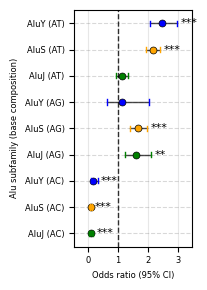

Subfamily Only ORs and p-values:
AluJ (AC): OR=0.10, Significance=***, p-value=0.000
AluS (AC): OR=0.10, Significance=***, p-value=0.000
AluY (AC): OR=0.18, Significance=***, p-value=0.638
AluJ (AG): OR=1.61, Significance=**, p-value=0.000
AluS (AG): OR=1.66, Significance=***, p-value=0.000
AluY (AG): OR=1.15, Significance=, p-value=0.000
AluJ (AT): OR=1.12, Significance=, p-value=0.221
AluS (AT): OR=2.14, Significance=***, p-value=0.000
AluY (AT): OR=2.47, Significance=***, p-value=0.001


In [11]:
# ------------------------------------------------
# Second figure: subfamily x base composition only
# ------------------------------------------------
# Prepare fresh lists so "All base comps" rows from the first figure are NOT included here
odds_ratios_bc = []
ci_lowers_bc = []
ci_uppers_bc = []
labels_bc = []
colors_bc = []
significance_vals_bc = []
base_comp_vals = []
pvalues_bc = []

for subfamily in subfamilies:
    for base_comp in base_comps:
        if len(base_comp) > 2:  # Skip base compositions that are too long for labeling
            continue
        odds_ratio, p_value, ci_lower, ci_upper = calculate_odds_ratio_for_columns(
            {'alu_subfamily': subfamily, 'base_composition': base_comp}, polya_outliers, 
            polya[(polya.alu_subfamily != "other") & (polya.detected_period > 2)]
        )
        p_value = bonferroni_correction([p_value])[0]
        odds_ratios_bc.append(odds_ratio)
        ci_lowers_bc.append(ci_lower)
        ci_uppers_bc.append(ci_upper)
        pvalues_bc.append(p_value)
        labels_bc.append(f"{subfamily} ({base_comp})")
        colors_bc.append(label_colors[subfamily])
        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        significance_vals_bc.append(significance)
        base_comp_vals.append(base_comp)

# Sort the data by base_comp then by subfamily
sorted_indices = sorted(
    range(len(labels_bc)),
    key=lambda i: (base_comp_vals[i], labels_bc[i].split(" ")[0])
)
labels_bc = [labels_bc[i] for i in sorted_indices]
odds_ratios_bc = [odds_ratios_bc[i] for i in sorted_indices]
ci_lowers_bc = [ci_lowers_bc[i] for i in sorted_indices]
ci_uppers_bc = [ci_uppers_bc[i] for i in sorted_indices]
colors_bc = [colors_bc[i] for i in sorted_indices]
significance_vals_bc = [significance_vals_bc[i] for i in sorted_indices]

fig, ax = plt.subplots(figsize=(2.5, 3))
y_positions = np.arange(len(labels_bc))
for i, (y, or_val, ci_low, ci_up, color) in enumerate(zip(y_positions, odds_ratios_bc, ci_lowers_bc, ci_uppers_bc, colors_bc)):
    if ci_up != float('inf'):
        ax.plot([ci_low, ci_up], [y, y], 'k-', linewidth=1, alpha=0.7)
    ax.plot(or_val, y, 'o', markersize=5, color=color, markeredgecolor='black', markeredgewidth=0.5)
    cap_size = 0.1
    ax.plot([ci_low, ci_low], [y - cap_size, y + cap_size], '-', color=color, linewidth=1)
    ax.plot([ci_up, ci_up], [y - cap_size, y + cap_size], '-', color=color, linewidth=1)
    ax.text((ci_up if ci_up != float('inf') else or_val) + 0.1, y, significance_vals_bc[i],
            color="black", fontsize=8, verticalalignment='center')

x_min_bc = min(min(ci_lowers_bc), min(odds_ratios_bc)) - 0.5
x_max_bc = max(max(odds_ratios_bc),
               max([ci_up if ci_up != float('inf') else or_val for or_val, ci_up in zip(odds_ratios_bc, ci_uppers_bc)])) + 0.5
ax.set_xlim(x_min_bc, x_max_bc)

ax.axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.8, label='OR = 1')
ax.set_yticks(y_positions)
ax.set_yticklabels(labels_bc)
ax.set_xlabel('Odds ratio (95% CI)', fontsize=label_size)
ax.set_ylabel('Alu subfamily (base composition)', fontsize=label_size)
ax.set_title("", fontsize=title_size)
ax.tick_params(axis='both', which='major', labelsize=label_size)
ax.grid(True, axis='x', alpha=0.3)
ax.grid(True, axis='y', color='grey', linestyle='--', alpha=0.3)
handles = [plt.Line2D([0], [0], color=color, marker='o', linestyle='', markersize=8, label=subfamily)
           for subfamily, color in label_colors.items()]
ax.legend(handles=handles, title="", loc="upper left", bbox_to_anchor=(1.02, 1),
          prop={'size': 8}, title_fontsize=8, fontsize=label_size)
ax.get_legend().remove()
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.savefig(plot_dir + "/figure_7_subfamily_basecomp.pdf", bbox_inches='tight', dpi=300)

plt.show()

# print all OR and pvalues
print("Subfamily Only ORs and p-values:")
for label, or_val, sig, p_val in zip(labels_bc, odds_ratios_bc, significance_vals_bc, pvalues_bc):
    print(f"{label}: OR={or_val:.2f}, Significance={sig}, p-value={p_val:.3f}")

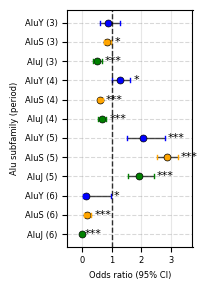

AluY (3): OR=0.89, Significance=, p-value=0.593
AluS (3): OR=0.85, Significance=*, p-value=0.037
AluJ (3): OR=0.49, Significance=***, p-value=0.000
AluY (4): OR=1.29, Significance=*, p-value=0.039
AluS (4): OR=0.62, Significance=***, p-value=0.000
AluJ (4): OR=0.65, Significance=***, p-value=0.000
AluY (5): OR=2.07, Significance=***, p-value=0.000
AluS (5): OR=2.86, Significance=***, p-value=0.000
AluJ (5): OR=1.94, Significance=***, p-value=0.000
AluY (6): OR=0.14, Significance=*, p-value=0.013
AluS (6): OR=0.15, Significance=***, p-value=0.000
AluJ (6): OR=0.00, Significance=***, p-value=0.000


In [29]:
# Calculate odds ratios for each subfamily-period pair
from matplotlib.pyplot import plot


labels = []
odds_ratios = []
ci_lowers = []
ci_uppers = []
colors = []
significance_vals = []
periods = []
subfamily_list = []
pvalues_bc = []

for subfamily in subfamilies:
    for period in sorted(polya.detected_period.unique()):
        if period <= 2 or period >6:  # Skip periods that are too short for labeling
            continue
        odds_ratio, p_value, ci_lower, ci_upper = calculate_odds_ratio_for_columns(
            {'alu_subfamily': subfamily, 'detected_period': period}, polya_outliers,
            polya[(polya.alu_subfamily != "other") & (polya.detected_period > 2)]
        )
        period_label = int(period) if float(period).is_integer() else period
        labels.append(f"{subfamily} ({period_label})")
        p_value = bonferroni_correction([p_value])[0]
        periods.append(period)
        subfamily_list.append(subfamily)
        odds_ratios.append(odds_ratio)
        ci_lowers.append(ci_lower)
        ci_uppers.append(ci_upper)
        pvalues_bc.append(p_value)
        colors.append(label_colors[subfamily])
        significance_vals.append(
            "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        )

# Order by period ascending, and within each period order AluY, AluS, AluJ
order_subfam = ["AluY", "AluS", "AluJ"]
sorted_indices = sorted(
    range(len(labels)),
    key=lambda i: (periods[i], order_subfam.index(subfamily_list[i]) if subfamily_list[i] in order_subfam else len(order_subfam))
)

labels = [labels[i] for i in sorted_indices]
odds_ratios = [odds_ratios[i] for i in sorted_indices]
ci_lowers = [ci_lowers[i] for i in sorted_indices]
ci_uppers = [ci_uppers[i] for i in sorted_indices]
colors = [colors[i] for i in sorted_indices]
significance_vals = [significance_vals[i] for i in sorted_indices]
periods = [periods[i] for i in sorted_indices]
subfamily_list = [subfamily_list[i] for i in sorted_indices]
pvalues_bc = [pvalues_bc[i] for i in sorted_indices]


x_min = min(
    min([v for v in odds_ratios if np.isfinite(v)] + [0]),
    min([v for v in ci_lowers if np.isfinite(v)] + [0])
) - 0.5
finite_ci_uppers = [v for v in ci_uppers if np.isfinite(v)]
x_max = max(
    max([v for v in odds_ratios if np.isfinite(v)] + [1]),
    max(finite_ci_uppers + [1])
) + 0.5

fig, ax = plt.subplots(figsize=(2.5, 3))
# Reverse y positions so the first (smallest period, AluY first) is at the top
y_positions = np.arange(len(labels))[::-1]

for i, (y, or_val, ci_low, ci_up, color) in enumerate(
    zip(y_positions, odds_ratios, ci_lowers, ci_uppers, colors)
):
    if np.isfinite(ci_up):
        ax.plot([ci_low, ci_up], [y, y], 'k-', linewidth=1, alpha=0.7)
    ax.plot(
        or_val,
        y,
        'o',
        markersize=5,
        color=color,
        markeredgecolor='black',
        markeredgewidth=0.5,
    )
    cap_size = 0.1
    if np.isfinite(ci_low):
        ax.plot([ci_low, ci_low], [y - cap_size, y + cap_size], '-', color=color, linewidth=1)
    if np.isfinite(ci_up):
        ax.plot([ci_up, ci_up], [y - cap_size, y + cap_size], '-', color=color, linewidth=1)

    if significance_vals[i]:
        x_text = ci_up + 0.1 if np.isfinite(ci_up) else or_val + 0.1
        x_text = min(x_text, x_max - 0.05)
        ax.text(x_text, y, significance_vals[i], color="black", fontsize=8, verticalalignment='center')

ax.axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.8, label='OR = 1')

ax.set_yticks(y_positions)
ax.set_yticklabels(labels, fontsize=label_size)
ax.set_xlabel('Odds ratio (95% CI)', fontsize=label_size)
ax.set_ylabel('Alu subfamily (period)', fontsize=label_size)
ax.set_title("", fontsize=title_size)
ax.tick_params(axis='both', which='major', labelsize=label_size)
ax.grid(True, axis='x', alpha=0.3)
ax.grid(True, axis='y', color='grey', linestyle='--', alpha=0.3)
ax.set_xlim(x_min, x_max)

handles = [
    plt.Line2D([0], [0], color=color, marker='o', linestyle='', markersize=8, label=subfamily)
    for subfamily, color in label_colors.items()
]
ax.legend(handles=handles, title="", loc="upper left", bbox_to_anchor=(1.02, 1),
          prop={'size': 8}, title_fontsize=8, fontsize=label_size)
ax.get_legend().remove()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig(plot_dir + "/figure_7_subfamily_periods.pdf", bbox_inches='tight', dpi=300)
plt.show()
for label, or_val, sig, p_val in zip(labels, odds_ratios, significance_vals, pvalues_bc):
    print(f"{label}: OR={or_val:.2f}, Significance={sig}, p-value={p_val:.3f}")

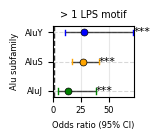

AluJ: Odds ratio = 13.74, p-value = 0.0002930378912420726, 95% CI = [4.92, 38.37]
AluS: Odds ratio = 26.76, p-value = 4.844786092169217e-26, 95% CI = [17.41, 41.13]
AluY: Odds ratio = 27.77, p-value = 2.278724570567783e-06, 95% CI = [10.65, 72.43]


In [13]:
# Calculate odds ratios for each subfamily-multiple_motifs pair
labels = []
odds_ratios = []
ci_lowers = []
ci_uppers = []
colors = []
significance_vals = []
pvalues_bc = []
polya["multiple_motifs"] = polya.num_total_lps_motifs > 1
polya_outliers["multiple_motifs"] = polya_outliers.num_total_lps_motifs > 1
for subfamily in subfamilies:
    for multi in [True]:
        odds_ratio, p_value, ci_lower, ci_upper = calculate_odds_ratio_for_columns(
            {'alu_subfamily': subfamily, 'multiple_motifs': multi}, polya_outliers, 
            polya[(polya.alu_subfamily != "other") & (polya.detected_period > 2)]
        )
        p_value = bonferroni_correction([p_value])[0]
        odds_ratios.append(odds_ratio)
        ci_lowers.append(ci_lower)
        ci_uppers.append(ci_upper)
        pvalues_bc.append(p_value)
        # remove parenthetical substring from label (keep only subfamily)
        labels.append(subfamily)
        colors.append(label_colors[subfamily])
        significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
        significance_vals.append(significance)

# Sort labels alphabetically
sorted_indices = sorted(range(len(labels)), key=lambda i: labels[i])
labels = [labels[i] for i in sorted_indices]
odds_ratios = [odds_ratios[i] for i in sorted_indices]
ci_lowers = [ci_lowers[i] for i in sorted_indices]
ci_uppers = [ci_uppers[i] for i in sorted_indices]
colors = [colors[i] for i in sorted_indices]
significance_vals = [significance_vals[i] for i in sorted_indices]
pvalues_bc = [pvalues_bc[i] for i in sorted_indices]


# Create the forest plot (formatted to match figure_7_subfamily style)
fig, ax = plt.subplots(figsize=(2, 1.5))
y_positions = np.arange(len(labels))

# Plot confidence intervals and odds ratios
for y, or_val, ci_low, ci_up, color, sig in zip(y_positions, odds_ratios, ci_lowers, ci_uppers, colors, significance_vals):
    if ci_up != float('inf'):
        ax.plot([ci_low, ci_up], [y, y], 'k-', linewidth=1, alpha=0.7)  # CI line
        ax.plot(or_val, y, 'o', markersize=5, color=color, markeredgecolor='black', markeredgewidth=0.5)  # OR point
        cap_size = 0.1
        ax.plot([ci_low, ci_low], [y - cap_size, y + cap_size], '-', color=color, linewidth=1)
        ax.plot([ci_up, ci_up], [y - cap_size, y + cap_size], '-', color=color, linewidth=1)
        ax.text((ci_up if ci_up != float('inf') else or_val) + 0.1, y, sig,
                color="black", fontsize=8, verticalalignment='center')

x_min = 0
x_max = max(max(odds_ratios),
            max([ci_up if ci_up != float('inf') else or_val
                 for or_val, ci_up in zip(odds_ratios, ci_uppers)])) + 0.5
ax.set_xlim(x_min, x_max)

ax.axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.8, label='OR = 1')
ax.set_yticks(y_positions)
ax.set_yticklabels(labels)
ax.set_ylabel('Alu subfamily', fontsize=label_size)
ax.set_xlabel('Odds ratio (95% CI)', fontsize=label_size)
ax.set_title("> 1 LPS motif", fontsize=title_size)
ax.tick_params(axis='both', which='major', labelsize=label_size)
ax.grid(True, axis='x', alpha=0.3)
ax.grid(True, axis='y', color='grey', linestyle='--', alpha=0.3)

handles = [plt.Line2D([0], [0], color=color, marker='o', linestyle='', markersize=8, label=subfamily)
           for subfamily, color in label_colors.items()]
ax.legend(handles=handles, title="", loc="upper left", bbox_to_anchor=(1.02, 1),
          prop={'size': 8}, title_fontsize=8, fontsize=label_size)

# don't include the legend
ax.get_legend().remove()

plt.tight_layout(rect=[0, 0, 0.85, 1])
# plt.savefig("figure_7_subfamily_multiplemotifs.pdf", bbox_inches='tight', dpi=300)
plt.show()

# print the Odds ratios, pvalues and CIs 
for label, or_val, p_val, ci_low, ci_up in zip(labels, odds_ratios, pvalues_bc, ci_lowers, ci_uppers):
    print(f"{label}: Odds ratio = {or_val:.2f}, p-value = {p_val}, 95% CI = [{ci_low:.2f}, {ci_up:.2f}]")


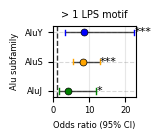

AluJ: Odds ratio = 4.26, p-value = 0.018076706604913558, 95% CI = [1.53, 11.90]
AluS: Odds ratio = 8.41, p-value = 1.7649794806080153e-14, 95% CI = [5.47, 12.94]
AluY: Odds ratio = 8.61, p-value = 0.0005304705966990216, 95% CI = [3.30, 22.47]


In [14]:
# Calculate odds ratios for each subfamily-multiple_motifs pair
labels = []
odds_ratios = []
ci_lowers = []
ci_uppers = []
colors = []
significance_vals = []
pvalues_bc = []

polya["multiple_motifs"] = polya["num_total_lps_motifs"] > 1
polya_outliers["multiple_motifs"] = polya_outliers["num_total_lps_motifs"] > 1

reference = polya[
    (polya["alu_subfamily"] != "other") &
    (polya["detected_period"] > 2) &
    (polya["unique_lps"] > 1)
]

for subfamily in subfamilies:
    odds_ratio, p_value, ci_lower, ci_upper = calculate_odds_ratio_for_columns(
        {"alu_subfamily": subfamily, "multiple_motifs": True},
        polya_outliers,
        reference
    )

    p_value = bonferroni_correction([p_value])[0]

    labels.append(subfamily)
    odds_ratios.append(odds_ratio)
    ci_lowers.append(ci_lower)
    ci_uppers.append(ci_upper)
    colors.append(label_colors[subfamily])
    pvalues_bc.append(p_value)
    significance_vals.append(
        "***" if p_value < 0.001 else
        "**" if p_value < 0.01 else
        "*" if p_value < 0.05 else ""
    )

# Sort labels alphabetically
sorted_indices = sorted(range(len(labels)), key=lambda i: labels[i])
labels = [labels[i] for i in sorted_indices]
odds_ratios = [odds_ratios[i] for i in sorted_indices]
ci_lowers = [ci_lowers[i] for i in sorted_indices]
ci_uppers = [ci_uppers[i] for i in sorted_indices]
colors = [colors[i] for i in sorted_indices]
significance_vals = [significance_vals[i] for i in sorted_indices]
pvalues_bc = [pvalues_bc[i] for i in sorted_indices]

# Create forest plot using figure_7_subfamily formatting
fig, ax = plt.subplots(figsize=(2, 1.5))
y_positions = np.arange(len(labels))

for y, or_val, ci_low, ci_up, color, sig in zip(
    y_positions,
    odds_ratios,
    ci_lowers,
    ci_uppers,
    colors,
    significance_vals
):
    if np.isfinite(ci_up):
        ax.plot([ci_low, ci_up], [y, y], "k-", linewidth=1, alpha=0.7)
        ax.plot(
            or_val, y, "o",
            markersize=5,
            color=color,
            markeredgecolor="black",
            markeredgewidth=0.5
        )

        cap_size = 0.1
        ax.plot(
            [ci_low, ci_low],
            [y - cap_size, y + cap_size],
            "-", color=color, linewidth=1
        )
        ax.plot(
            [ci_up, ci_up],
            [y - cap_size, y + cap_size],
            "-", color=color, linewidth=1
        )

        if sig:
            ax.text(
                ci_up + 0.1, y, sig,
                color="black",
                fontsize=8,
                verticalalignment="center"
            )

x_max = max(
    max(odds_ratios),
    max(ci_up for ci_up in ci_uppers if np.isfinite(ci_up))
) + 0.5

ax.set_xlim(0, x_max)
ax.axvline(1, color="black", linestyle="--", linewidth=1, alpha=0.8)

ax.set_yticks(y_positions)
ax.set_yticklabels(labels)
ax.set_ylabel("Alu subfamily", fontsize=label_size)
ax.set_xlabel("Odds ratio (95% CI)", fontsize=label_size)
ax.set_title("> 1 LPS motif", fontsize=title_size)
ax.tick_params(axis="both", which="major", labelsize=label_size)

ax.grid(True, axis="x", alpha=0.3)
ax.grid(True, axis="y", color="grey", linestyle="--", alpha=0.3)

ax.get_legend() and ax.get_legend().remove()

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.savefig(
    plot_dir + "/figure_7_subfamily_multiplemotifs.pdf",
    bbox_inches="tight",
    dpi=300
)
plt.show()

for label, or_val, p_val, ci_low, ci_up in zip(
    labels, odds_ratios, pvalues_bc, ci_lowers, ci_uppers
):
    print(
        f"{label}: Odds ratio = {or_val:.2f}, "
        f"p-value = {p_val}, "
        f"95% CI = [{ci_low:.2f}, {ci_up:.2f}]"
    )


## Outlier LPS metric scatter plot

In [15]:
# REVISED use the refseq names, I output the mapping
gene_name_mappings = pd.read_csv("/nfs/boylelab_turbo/kvandeyn/MEI_STR/data/TR_catalog_HPRC/gene_annotations_to_locusID.csv")
# just add this to LPS overall on locusID 
polya_outliers = polya_outliers.merge(gene_name_mappings,on="LocusID", how="left")
polya_outliers_intron = polya_outliers[polya_outliers['GencodeGeneRegion'] == 'intron']

In [16]:
gene_name_mappings

,LocusID,GencodeGeneName,GencodeGeneId,RefseqGeneName,RefseqGeneId,ManeGeneName,ManeGeneId
0,15,DDX11L2,ENSG00000290825,DDX11L1,DDX11L1,NaN,NaN
1,16,WASH7P,ENSG00000227232,WASH7P,WASH7P,NaN,NaN
2,17,WASH7P,ENSG00000227232,WASH7P,WASH7P,NaN,NaN
3,18,WASH7P,ENSG00000227232,WASH7P,WASH7P,NaN,NaN
4,19,WASH7P,ENSG00000227232,WASH7P,WASH7P,NaN,NaN
...,...,...,...,...,...,...,...
2382686,4542948,NaN,NaN,NaN,NaN,NaN,NaN
2382687,4542949,NaN,NaN,NaN,NaN,NaN,NaN
2382688,4542950,NaN,NaN,NaN,NaN,NaN,NaN
2382689,4542951,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
# check how often the GencodGeneName GencodGeneID and RefseqGeneName match are all null
# merge onto outlier_data_intron
print((~polya_outliers_intron[["GencodeGeneName", "GencodeGeneId", "RefseqGeneName"]].isnull()).sum())
# how often are the RefSeqGeneName and GencodeGeneName the same when both are not null
print((polya_outliers_intron[~polya_outliers_intron["GencodeGeneName"].isnull() & ~polya_outliers_intron["RefseqGeneName"].isnull()].apply(lambda row: row["GencodeGeneName"] == row["RefseqGeneName"], axis=1)).sum())
# how often are the GencodeGeneId and the GencodeGeneName the same when both are not null
print((polya_outliers_intron[~polya_outliers_intron["GencodeGeneName"].isnull() & ~polya_outliers_intron["GencodeGeneId"].isnull()].apply(lambda row: row["GencodeGeneName"] in row["GencodeGeneId"], axis=1)).sum())

# add a column called "GeneName" that takes the GencodeGeneName if it is not equal to the GencodeGeneId, otherwise takes the RefseqGeneName if it is not null, otherwise takes the GencodeGeneId
def choose_gene_name(row):
    if pd.notnull(row["GencodeGeneName"]) and row["GencodeGeneName"] not in row["GencodeGeneId"]:
        return row["GencodeGeneName"]
    elif pd.notnull(row["RefseqGeneName"]):
        return row["RefseqGeneName"]
    else:
        return row["GencodeGeneId"]
polya_outliers_intron["GeneName"] = polya_outliers_intron.apply(choose_gene_name, axis=1)
polya_outliers_intron[["LocusID", "GeneName", "Mean", "unique_lps", "num_total_lps_motifs", "simple_motif"]].sort_values("unique_lps", ascending=False).head(20)

GencodeGeneName    716
GencodeGeneId      716
RefseqGeneName     630
dtype: int64
561
95


/tmp/ipykernel_3225616/2828372913.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  polya_outliers_intron["GeneName"] = polya_outliers_intron.apply(choose_gene_name, axis=1)


,LocusID,GeneName,Mean,unique_lps,num_total_lps_motifs,simple_motif
76,1060483.0,KCNIP4,105.732984,46.0,2.0,AAAAT
670,1087753.0,RFC1,106.006098,38.0,3.0,AAAAG
159,536171.0,RGPD8,65.631868,32.0,2.0,AAAAG
909,4127669.0,RIPOR3,79.140625,31.0,3.0,AAAAG
1155,2723693.0,RPL29P21,68.148148,29.0,3.0,AAAAG
465,3631877.0,BEAN1,73.698980,28.0,3.0,AAAAT
586,3167622.0,ENSG00000287722,71.893048,28.0,1.0,AAAG
1222,1414688.0,ARHGEF28,92.182741,27.0,1.0,AAAAG
1058,2922783.0,RERG,88.577540,25.0,1.0,AAAG
304,1049543.0,LINC01182,60.865979,22.0,1.0,AAAG


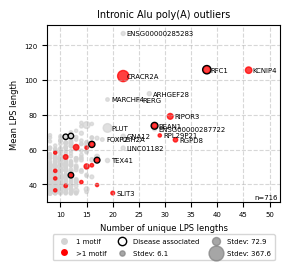

In [27]:
# Single scatter plot: all points together
# Single scatter plot: all points together
plot_df = polya_outliers_intron.copy()

# Masks
multi_mask = plot_df["num_total_lps_motifs"].gt(1)

# Use the bool disease column if present, otherwise coerce from disease_associated
if "disease_associated_y" in plot_df.columns:
    disease_mask = plot_df["disease_associated_y"].astype(bool)
else:
    disease_mask = plot_df["disease_associated"].astype(str).str.lower().isin(["true", "1", "yes"])

# Scale point size by Stdev
stdev = plot_df["Stdev"].fillna(plot_df["Stdev"].median())
if stdev.max() == stdev.min():
    sizes = np.full(len(plot_df), 80.0)
else:
    sizes = 5 + (stdev - stdev.min()) / (stdev.max() - stdev.min()) * 60  # 30..300

fig, ax = plt.subplots(figsize=(3, 3))

# add a grid
ax.grid(True, linestyle='--', alpha=0.5)

# Non-multiple motifs (gray)
ax.scatter(
    plot_df.loc[~multi_mask, "unique_lps"],
    plot_df.loc[~multi_mask, "Mean"],
    s=sizes[~multi_mask],
    c="lightgray",
    alpha=0.7,
    label="1 motif"
)

# Multiple motifs (red)
ax.scatter(
    plot_df.loc[multi_mask, "unique_lps"],
    plot_df.loc[multi_mask, "Mean"],
    s=sizes[multi_mask],
    c="red",
    alpha=0.75,
    label=">1 motif"
)

# Circle disease-associated points
ax.scatter(
    plot_df.loc[disease_mask, "unique_lps"],
    plot_df.loc[disease_mask, "Mean"],
    s=sizes[disease_mask] + 10,
    facecolors="none",
    edgecolors="black",
    linewidths=1,
    label="Disease associated"
)

# Add gene labels for num_unique_lps > 20
gene_col = "GeneName"
if gene_col is not None:
    label_rows = plot_df.loc[(plot_df["unique_lps"] > 17), ["unique_lps", "Mean", gene_col]]
    for _, r in label_rows.iterrows():
        g = str(r[gene_col]).strip()
        if g and g.lower() != "nan":
            ax.text(r["unique_lps"] + 0.7, r["Mean"], g, fontsize=tick_size, va="center", ha="left")

ax.set_title("Intronic Alu poly(A) outliers", fontsize=title_size)
ax.set_xlabel("Number of unique LPS lengths", fontsize=label_size)
ax.set_ylabel("Mean LPS length", fontsize=label_size)
ax.tick_params(axis="both", labelsize=tick_size)

# Create size legend handles and labels
# pick a large-but-intermediate stdev for the middle example (90th percentile)
min_v = stdev.min()
max_v = stdev.max()
mid_v = np.percentile(stdev, 99)

size_values = [min_v, mid_v, max_v]
size_points = [10 + (v - min_v) / (max_v - min_v) * 70 for v in size_values]
size_labels = [f"Stdev: {v:.1f}" for v in size_values]

size_handles = [plt.scatter([], [], s=s, c="gray", alpha=0.7) for s in size_points]

# Put motif/disease entries first, then the stdev examples after them
motif_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray', markersize=5, label='1 motif'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=5, label='>1 motif'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='black', markersize=5, label='Disease associated')
]

all_handles = motif_handles + size_handles
all_labels = ['1 motif', '>1 motif', 'Disease associated'] + size_labels
ax.legend(
    all_handles,
    all_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=3,
    fontsize=tick_size,
    markerscale=1.2,
    handlelength=2.2,
    handletextpad=0.5,
    columnspacing=1.2,
    labelspacing=0.8,
    borderpad=0.6,
    frameon=True
)

# Add n
ax.text(
    0.99, 0.01, f"n={len(plot_df)}",
    transform=ax.transAxes, ha="right", va="bottom", fontsize=tick_size
)

# Expand x-limits so right-side gene labels don't touch/overlap the border
x_min = plot_df["unique_lps"].min()
x_max = plot_df["unique_lps"].max()
ax.set_xlim(max(0, x_min - 0.5), x_max + 6.0)

plt.tight_layout()
plt.savefig(plot_dir + "/figure_7_outlier_scatter_grid.pdf", dpi=300, bbox_inches='tight')

plt.show()



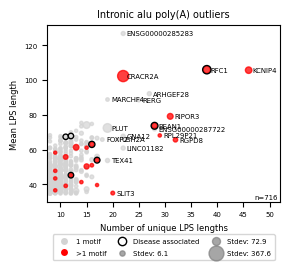

In [19]:
# Single scatter plot: all points together
# Single scatter plot: all points together
plot_df = polya_outliers_intron.copy()

# Masks
multi_mask = plot_df["num_total_lps_motifs"].gt(1)

# Use the bool disease column if present, otherwise coerce from disease_associated
if "disease_associated_y" in plot_df.columns:
    disease_mask = plot_df["disease_associated_y"].astype(bool)
else:
    disease_mask = plot_df["disease_associated"].astype(str).str.lower().isin(["true", "1", "yes"])

# Scale point size by Stdev
stdev = plot_df["Stdev"].fillna(plot_df["Stdev"].median())
if stdev.max() == stdev.min():
    sizes = np.full(len(plot_df), 80.0)
else:
    sizes = 5 + (stdev - stdev.min()) / (stdev.max() - stdev.min()) * 60  # 30..300

fig, ax = plt.subplots(figsize=(3, 3))

# Non-multiple motifs (gray)
ax.scatter(
    plot_df.loc[~multi_mask, "unique_lps"],
    plot_df.loc[~multi_mask, "Mean"],
    s=sizes[~multi_mask],
    c="lightgray",
    alpha=0.7,
    label="1 motif"
)

# Multiple motifs (red)
ax.scatter(
    plot_df.loc[multi_mask, "unique_lps"],
    plot_df.loc[multi_mask, "Mean"],
    s=sizes[multi_mask],
    c="red",
    alpha=0.75,
    label=">1 motif"
)

# Circle disease-associated points
ax.scatter(
    plot_df.loc[disease_mask, "unique_lps"],
    plot_df.loc[disease_mask, "Mean"],
    s=sizes[disease_mask] + 10,
    facecolors="none",
    edgecolors="black",
    linewidths=1,
    label="Disease associated"
)

# Add gene labels for num_unique_lps > 20
gene_col = "GeneName"
if gene_col is not None:
    label_rows = plot_df.loc[(plot_df["unique_lps"] > 17), ["unique_lps", "Mean", gene_col]]
    for _, r in label_rows.iterrows():
        g = str(r[gene_col]).strip()
        if g and g.lower() != "nan":
            ax.text(r["unique_lps"] + 0.7, r["Mean"], g, fontsize=tick_size, va="center", ha="left")

ax.set_title("Intronic alu poly(A) outliers", fontsize=title_size)
ax.set_xlabel("Number of unique LPS lengths", fontsize=label_size)
ax.set_ylabel("Mean LPS length", fontsize=label_size)
ax.tick_params(axis="both", labelsize=tick_size)

# Create size legend handles and labels
# pick a large-but-intermediate stdev for the middle example (90th percentile)
min_v = stdev.min()
max_v = stdev.max()
mid_v = np.percentile(stdev, 99)

size_values = [min_v, mid_v, max_v]
size_points = [10 + (v - min_v) / (max_v - min_v) * 70 for v in size_values]
size_labels = [f"Stdev: {v:.1f}" for v in size_values]

size_handles = [plt.scatter([], [], s=s, c="gray", alpha=0.7) for s in size_points]

# Put motif/disease entries first, then the stdev examples after them
motif_handles = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='lightgray', markersize=5, label='1 motif'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='red', markersize=5, label='>1 motif'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='none', markeredgecolor='black', markersize=5, label='Disease associated')
]

all_handles = motif_handles + size_handles
all_labels = ['1 motif', '>1 motif', 'Disease associated'] + size_labels
ax.legend(
    all_handles,
    all_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.35),
    ncol=3,
    fontsize=tick_size,
    markerscale=1.2,
    handlelength=2.2,
    handletextpad=0.5,
    columnspacing=1.2,
    labelspacing=0.8,
    borderpad=0.6,
    frameon=True
)

# Add n
ax.text(
    0.99, 0.01, f"n={len(plot_df)}",
    transform=ax.transAxes, ha="right", va="bottom", fontsize=tick_size
)

# Expand x-limits so right-side gene labels don't touch/overlap the border
x_min = plot_df["unique_lps"].min()
x_max = plot_df["unique_lps"].max()
ax.set_xlim(max(0, x_min - 0.5), x_max + 6.0)

plt.tight_layout()

# save
plt.savefig(plot_dir + "/figure_7_outlier_scatter.pdf", dpi=300, bbox_inches='tight')

plt.show()



In [20]:
print(plot_dir + "/figure_7_outlier_scatter.pdf")

/home/kvandeyn/MEI_STR/scripts/notebooks/MEI_STR/manuscript_figures/figure_7_redone/figure_7_outlier_scatter.pdf


# Supplemental Sequence Polymorphism

In [22]:
# get outliers from the overall set so we can assess sequence polymorphism in outliers vs overall
LPS_variable = LPS[(LPS.unique_lps > 1)& (LPS.detected_period >2) & (LPS.detected_period <=6)]
LPS_3_to_6 = LPS[(LPS.detected_period >2) & (LPS.detected_period <=6)]
# Identify outlier loci
# Get rows in the top 95th percentile of unique_lps
unique_lps_95 = LPS_variable['unique_lps'].quantile(0.95)
print(f"95th percentile threshold for unique_lps: {unique_lps_95}")

# Get all rows that are in the top 80th percentile (>= 80th percentile)
top_95th_percentile_rows = LPS_variable[LPS_variable['unique_lps'] >= unique_lps_95]
print(f"Number of rows in top 95th percentile: {len(top_95th_percentile_rows)}")
print(f"Percentage of total rows: {len(top_95th_percentile_rows) / len(LPS[LPS.detected_period > 2]) * 100:.1f}%")
print(f"Percentage of variable rows: {len(top_95th_percentile_rows) / len(LPS_variable) * 100:.1f}%")

# Display some basic statistics
print(f"\nUnique_lps statistics for top 95th percentile:")
print(f"Min: {top_95th_percentile_rows['unique_lps'].min()}")
print(f"Max: {top_95th_percentile_rows['unique_lps'].max()}")
print(f"Mean: {top_95th_percentile_rows['unique_lps'].mean():.2f}")

# print the number of disease_associated regions and which ones are in this set
print(f"\nNumber of disease associated regions in top 95th percentile: {top_95th_percentile_rows[top_95th_percentile_rows['disease_associated']].shape[0]}")
print(f"Percentage of disease associated regions in top 95th percentile: {top_95th_percentile_rows[top_95th_percentile_rows['disease_associated']].shape[0] / LPS_3_to_6[LPS_3_to_6['disease_associated']].shape[0] * 100:.1f}%")

# Get the rows in the top 90th percentile of Mean
mean_threshold = LPS_variable['Mean'].quantile(0.90)
Mean_outliers = LPS_variable[LPS_variable['Mean'] > mean_threshold]

# print the summary
print(f"Number of rows in Mean outliers: {len(Mean_outliers)}")
print(f"Percentage of total rows: {len(Mean_outliers) / len(LPS_3_to_6) * 100:.1f}%")
print(f"Percentage of variable rows: {len(Mean_outliers) / len(LPS_variable) * 100:.1f}%")

print(f"\nMean statistics for Mean outliers:")
print(f"Min: {Mean_outliers['Mean'].min()}")
print(f"Max: {Mean_outliers['Mean'].max()}")
print(f"Mean: {Mean_outliers['Mean'].mean():.2f}")

# print the number of disease_associated regions and which ones are in this set
print(f"\nNumber of disease associated regions in Mean outliers: {Mean_outliers[Mean_outliers['disease_associated']].shape[0]}")
print(f"Percentage of disease associated regions in Mean outliers: {Mean_outliers[Mean_outliers['disease_associated']].shape[0] / LPS_3_to_6[LPS_3_to_6['disease_associated']].shape[0] * 100:.1f}%")

# Get the 95th percentile of Stdev
std_threshold = LPS_variable['Stdev'].quantile(0.95)
Stdev_outliers = LPS_variable[LPS_variable['Stdev'] > std_threshold]

# print the summary
print(f"Number of rows in Stdev outliers: {len(Stdev_outliers)}")
print(f"Percentage of total rows: {len(Stdev_outliers) / len(LPS_3_to_6) * 100:.1f}%")
print(f"Percentage of variable rows: {len(Stdev_outliers) / len(LPS_variable) * 100:.1f}%")

print(f"Percentage of variable rows: {len(Stdev_outliers) / len(LPS_variable) * 100:.1f}%")

print(f"\nMean statistics for Stdev outliers:")
print(f"Min: {Stdev_outliers['Stdev'].min()}")
print(f"Max: {Stdev_outliers['Stdev'].max()}")
print(f"Mean: {Stdev_outliers['Stdev'].mean():.2f}")

# print the number of disease_associated regions and which ones are in this set
print(f"\nNumber of disease associated regions in Stdev outliers: {Stdev_outliers[Stdev_outliers['disease_associated']].shape[0]}")
print(f"Percentage of disease associated regions in Stdev outliers: {Stdev_outliers[Stdev_outliers['disease_associated']].shape[0] / LPS_3_to_6[LPS_3_to_6['disease_associated']].shape[0] * 100:.1f}%")


95th percentile threshold for unique_lps: 6.0
Number of rows in top 95th percentile: 16075
Percentage of total rows: 0.9%
Percentage of variable rows: 6.2%

Unique_lps statistics for top 95th percentile:
Min: 6
Max: 55
Mean: 7.70

Number of disease associated regions in top 95th percentile: 42
Percentage of disease associated regions in top 95th percentile: 77.8%
Number of rows in Mean outliers: 26055
Percentage of total rows: 1.5%
Percentage of variable rows: 10.0%

Mean statistics for Mean outliers:
Min: 25.602094240837697
Max: 170.02551020408163
Mean: 35.59

Number of disease associated regions in Mean outliers: 42
Percentage of disease associated regions in Mean outliers: 77.8%
Number of rows in Stdev outliers: 13030
Percentage of total rows: 0.7%
Percentage of variable rows: 5.0%
Percentage of variable rows: 5.0%

Mean statistics for Stdev outliers:
Min: 4.488422772192455
Max: 367.6377669245515
Mean: 7.02

Number of disease associated regions in Stdev outliers: 40
Percentage of di

In [23]:
# take the intersection of the three outlier sets to get the overall outliers
outliers = set(Mean_outliers.index).intersection(set(Stdev_outliers.index)).intersection(set(top_95th_percentile_rows.index))
outliers = LPS_variable.loc[list(outliers)]
print(f"Number of overall outliers: {len(outliers)}")
print(f"Percentage of total rows: {len(outliers) / len(LPS) * 100:.1f}%")
print(f"Percentage of variable rows: {len(outliers) / len(LPS_variable) * 100:.1f}%")

# print the summary stats for each metric
# Mean
print()
print("Mean Mean LPS length in outliers: ", outliers["Mean"].mean())
print("The Mean LPS length range in outliers was (", outliers["Mean"].min(),",",outliers["Mean"].max(),")")
print()
print("Mean Standard Deviation LPS length in outliers: ", outliers["Stdev"].mean())
print("The Standard Deviation LPS length range in outliers was (", outliers["Stdev"].min(),",",outliers["Stdev"].max(),")")
print()
print("Mean number of unique LPS lengths in outliers: ", outliers["unique_lps"].mean())
print("The number of unique LPS lengths range in outliers was (", outliers["unique_lps"].min(),",",outliers["unique_lps"].max(),")")
print()



# print the disease_associated regions disease_id that are in and not in the overall outliers
print(f"Total variable disease associated regions: {LPS_variable[LPS_variable['disease_associated']].shape[0]}")
print(f"Disease associated regions in overall outliers: {outliers[outliers['disease_associated']].disease_id.tolist()}")
print(f"Disease associated regions not in overall outliers: {LPS_variable[~LPS_variable.index.isin(outliers.index) & LPS_variable['disease_associated']]['disease_id'].tolist()}")

# Get the odds ratio for the disease associated regions in outliers vs not in outliers for variable regions only using a fisher's exact test

# Perform the test
contingency_table = [[outliers[outliers['disease_associated']].shape[0], outliers[~outliers['disease_associated']].shape[0]],
                     [LPS_variable[~LPS_variable.index.isin(outliers.index) & LPS_variable['disease_associated']].shape[0], LPS_variable[~LPS_variable.index.isin(outliers.index) & ~LPS_variable['disease_associated']].shape[0]]]
odds_ratio, p_value = fisher_exact(contingency_table)
print("\nFisher's exact test results, disease associated regions in outlier set vs non-outlier set (variable regions only):")
print(f"Odds ratio: {odds_ratio:.2f}, P-value: {p_value}")

Number of overall outliers: 9782
Percentage of total rows: 0.4%
Percentage of variable rows: 3.8%

Mean Mean LPS length in outliers:  39.824464684701134
The Mean LPS length range in outliers was ( 25.604166666666668 , 170.02551020408163 )

Mean Standard Deviation LPS length in outliers:  7.388786293743482
The Standard Deviation LPS length range in outliers was ( 4.488532475463157 , 367.6377669245515 )

Mean number of unique LPS lengths in outliers:  8.308321406665303
The number of unique LPS lengths range in outliers was ( 6 , 55 )

Total variable disease associated regions: 48
Disease associated regions in overall outliers: ['DM1', 'SCA31', 'SCA17', 'DM2', 'SCA2', 'FAME6', 'FECD', 'SCA6', 'OPDM2', 'ALS.FTD', 'FAME2', 'NIID', 'FRA2A', 'HSAN8', 'FAME4', 'SCA36', 'FXS', 'FRAXE', 'DRPLA', 'SBMA', 'OPDM1', 'SCA37', 'OPML1', 'HDL2', 'GAD', 'SCA8', 'FAME7', 'FAME3', 'DMD', 'FA', 'CANVAS', 'SCA27B', 'SCA10', 'HD', 'BSS', 'FAME1', 'FRA11B', 'SCA3', 'SCA12']
Disease associated regions not in ov

## Sequence polymorphism by mei family and position regardless of length and overall polymorphism

MEI Family: Alu, Terminal Position: internal => OR: 0.444, CI: (0.351, 0.563), p-value: 2.268e-14 ***
MEI Family: Alu, Terminal Position: 3'terminal => OR: 0.750, CI: (0.667, 0.844), p-value: 8.678e-07 ***
MEI Family: Alu, Terminal Position: 5'terminal => OR: 1.394, CI: (1.006, 1.931), p-value: 5.048e-02 
MEI Family: SVA, Terminal Position: internal => OR: 0.694, CI: (0.097, 4.947), p-value: 1.000e+00 
MEI Family: SVA, Terminal Position: 3'terminal => OR: 1.507, CI: (0.374, 6.067), p-value: 3.846e-01 
MEI Family: SVA, Terminal Position: 5'terminal => OR: 4.119, CI: (2.320, 7.312), p-value: 6.090e-05 ***
MEI Family: LINE1, Terminal Position: internal => OR: 0.694, CI: (0.601, 0.800), p-value: 1.611e-07 ***
MEI Family: LINE1, Terminal Position: 3'terminal => OR: 0.917, CI: (0.732, 1.150), p-value: 5.059e-01 
MEI Family: LINE1, Terminal Position: 5'terminal => OR: 1.062, CI: (0.815, 1.386), p-value: 6.253e-01 
MEI Family: LINE2, Terminal Position: internal => OR: 0.414, CI: (0.260, 0.659)

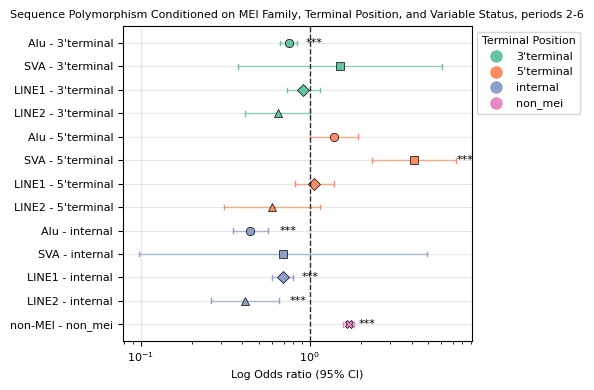

In [24]:
major_families = ['Alu', 'SVA', 'LINE1', 'LINE2', 'non-MEI']
conditional_enrichment_values = {}
LPS['mei_family_plot'] = LPS['mei_family'].replace({'SINE_Alu':'Alu', 'Retroposon_SVA':'SVA', 'LINE_L1':'LINE1', 'LINE_L2':'LINE2', 'non_mei':'non-MEI'})
LPS["variable"] = LPS.unique_lps > 1
LPS["multiple_motifs"] = LPS.num_total_lps_motifs > 1
# only include major families and non-MEI in the analysis
# Iterate over unique combinations of mei_family_plot and terminal_position
# Initialize a dictionary to store the results
conditional_enrichment_values = {}
multiple_motifs = LPS[LPS['multiple_motifs'] == True]

# Iterate over unique combinations of mei_family_plot and terminal_position
for mei_family in major_families:
    for terminal_pos in LPS['terminal_label'].unique():
        # Skip invalid combinations based on the conditions
        if mei_family == "non-MEI" and terminal_pos != "non_mei":
            continue
        elif mei_family != "non-MEI" and terminal_pos == "non_mei":
            continue

        # Calculate odds ratios, p-values, and confidence intervals
        odds_ratio, p_value, ci_lower, ci_upper = calculate_odds_ratio_for_columns(
            {'mei_family_plot':mei_family,"terminal_label":terminal_pos}, multiple_motifs, LPS[(LPS['variable'])]
        )
        
        # Save the results in the dictionary
        conditional_enrichment_values[(mei_family, terminal_pos)] = (odds_ratio, p_value, ci_lower, ci_upper)

# Print the results
for (mei_family, terminal_pos), (odds_ratio, p_value, ci_lower, ci_upper) in conditional_enrichment_values.items():
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    print(f"MEI Family: {mei_family}, Terminal Position: {terminal_pos} => OR: {odds_ratio:.3f}, CI: ({ci_lower:.3f}, {ci_upper:.3f}), p-value: {p_value:.3e} {significance}")

# plot a forest plot for all of the results above, with different colors for each mei_family_plot and terminal_label combination, and include confidence intervals and p-values in the plot, don't include the nan group in the plot
# Prepare data for plotting
sample_odds_ratios = []
sample_ci_lowers = []
sample_ci_uppers = []
sample_labels = []
sample_colors = []
sample_significance = []
# plot each terminal_label in a different color and use different markers for each mei_family_plot
label_colors = {
    "3'terminal": plt.get_cmap('Set2')(0),
    "5'terminal": plt.get_cmap('Set2')(1),
    "internal": plt.get_cmap('Set2')(2),
    "non_mei": plt.get_cmap('Set2')(3)
}
marker_styles = {
    "Alu": 'o',
    "SVA": 's',
    "LINE1": 'D',
    "LINE2": '^',
    "non-MEI": 'X'
}
for (mei_family, terminal_pos), (odds_ratio, p_value, ci_lower, ci_upper) in conditional_enrichment_values.items():
    if pd.isna(mei_family) or pd.isna(terminal_pos):
        continue
    sample_odds_ratios.append(odds_ratio)
    sample_ci_lowers.append(ci_lower)
    sample_ci_uppers.append(ci_upper)
    sample_labels.append(f"{mei_family} - {terminal_pos}")
    sample_colors.append(label_colors.get(terminal_pos, "gray"))
    sample_significance.append("***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "")

fig, ax = plt.subplots(figsize=(6, 4))
# Sort sample_labels by terminal_label (extract from label string)
sorted_indices = sorted(range(len(sample_labels)), key=lambda i: sample_labels[i].split(" - ")[1])
sample_odds_ratios = [sample_odds_ratios[i] for i in sorted_indices]
sample_ci_lowers = [sample_ci_lowers[i] for i in sorted_indices]
sample_ci_uppers = [sample_ci_uppers[i] for i in sorted_indices]
sample_labels = [sample_labels[i] for i in sorted_indices]
sample_colors = [sample_colors[i] for i in sorted_indices]
sample_significance = [sample_significance[i] for i in sorted_indices]
y_positions = np.arange(len(sample_labels))[::-1]
for i, (y, or_val, ci_low, ci_up, color, label) in enumerate(zip(y_positions, sample_odds_ratios, sample_ci_lowers, sample_ci_uppers, sample_colors, sample_labels)):
    if ci_up != float('inf'):
        ax.plot([ci_low, ci_up], [y, y], '-', color=color, linewidth=1, alpha=0.7)
    marker = marker_styles.get(label.split(" - ")[0], 'o')
    ax.plot(or_val, y, marker, markersize=6, color=color, markeredgecolor='black', markeredgewidth=0.5)
    cap_size = 0.1
    ax.plot([ci_low, ci_low], [y - cap_size, y + cap_size], '-', color=color, linewidth=1)
    ax.plot([ci_up, ci_up], [y - cap_size, y + cap_size], '-', color=color, linewidth=1)
    ax.text(ci_up + 0.1, y, sample_significance[i], color="black", fontsize=8, verticalalignment='center')

ax.axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.8, label='OR = 1')
ax.set_yticks(y_positions)
ax.set_yticklabels(sample_labels, fontsize=8)
ax.set_xlabel('Log Odds ratio (95% CI)', fontsize=8)
ax.tick_params(axis='x', labelsize=8)
ax.set_xscale('log')
ax.set_title("Sequence Polymorphism Conditioned on MEI Family, Terminal Position, and Variable Status, periods 2-6", fontsize=8)
ax.grid(True, axis='both', alpha=0.3)
handles = [plt.Line2D([0], [0], color=color, marker='o', linestyle='', markersize=8, label=label) for label, color in label_colors.items()]
ax.legend(handles=handles, title="Terminal Position", loc="upper left", bbox_to_anchor=(1, 1), fontsize=8, title_fontsize=8)
plt.tight_layout()
plt.show()

/tmp/ipykernel_3225616/3407666450.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  LPS_3_to_6['mei_family_plot'] = LPS_3_to_6['mei_family'].replace({'SINE_Alu':'Alu', 'Retroposon_SVA':'SVA', 'LINE_L1':'LINE1', 'LINE_L2':'LINE2', 'non_mei':'non-TE'})
/tmp/ipykernel_3225616/3407666450.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  LPS_3_to_6["variable"] = LPS_3_to_6.unique_lps > 1
/tmp/ipykernel_3225616/3407666450.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

MEI Family: Alu, Terminal Position: internal => OR: 0.394, CI: (0.302, 0.515), p-value: 3.058e-15 ***
MEI Family: Alu, Terminal Position: 5'terminal => OR: 1.644, CI: (1.150, 2.350), p-value: 1.034e-02 *
MEI Family: Alu, Terminal Position: 3'terminal => OR: 0.600, CI: (0.522, 0.689), p-value: 2.374e-14 ***
MEI Family: SVA, Terminal Position: internal => OR: 0.730, CI: (0.102, 5.210), p-value: 1.000e+00 
MEI Family: SVA, Terminal Position: 5'terminal => OR: 4.184, CI: (2.354, 7.436), p-value: 5.341e-05 ***
MEI Family: SVA, Terminal Position: 3'terminal => OR: 1.530, CI: (0.380, 6.162), p-value: 3.779e-01 
MEI Family: LINE1, Terminal Position: internal => OR: 0.733, CI: (0.611, 0.880), p-value: 6.427e-04 ***
MEI Family: LINE1, Terminal Position: 5'terminal => OR: 0.894, CI: (0.606, 1.319), p-value: 6.386e-01 
MEI Family: LINE1, Terminal Position: 3'terminal => OR: 0.819, CI: (0.606, 1.106), p-value: 2.084e-01 
MEI Family: LINE2, Terminal Position: internal => OR: 0.368, CI: (0.197, 0.685

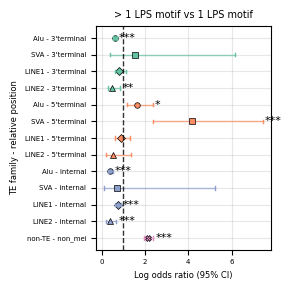

In [25]:
major_families = ['Alu', 'SVA', 'LINE1', 'LINE2', 'non-TE']
conditional_enrichment_values = {}
LPS_3_to_6['mei_family_plot'] = LPS_3_to_6['mei_family'].replace({'SINE_Alu':'Alu', 'Retroposon_SVA':'SVA', 'LINE_L1':'LINE1', 'LINE_L2':'LINE2', 'non_mei':'non-TE'})
LPS_3_to_6["variable"] = LPS_3_to_6.unique_lps > 1
LPS_3_to_6["multiple_motifs"] = LPS_3_to_6.num_total_lps_motifs > 1
# only include major families and non-MEI in the analysis
# Iterate over unique combinations of mei_family_plot and terminal_position
# Initialize a dictionary to store the results
conditional_enrichment_values = {}
multiple_motifs = LPS_3_to_6[LPS_3_to_6['multiple_motifs'] == True]

# Iterate over unique combinations of mei_family_plot and terminal_position
for mei_family in major_families:
    for terminal_pos in LPS_3_to_6['terminal_label'].unique():
        # Skip invalid combinations based on the conditions
        if mei_family == "non-TE" and terminal_pos != "non_mei":
            continue
        elif mei_family != "non-TE" and terminal_pos == "non_mei":
            continue

        # Calculate odds ratios, p-values, and confidence intervals
        odds_ratio, p_value, ci_lower, ci_upper = calculate_odds_ratio_for_columns(
            {'mei_family_plot':mei_family,"terminal_label":terminal_pos}, multiple_motifs, LPS_3_to_6[(LPS_3_to_6['variable'])]
        )
        
        # Save the results in the dictionary
        conditional_enrichment_values[(mei_family, terminal_pos)] = (odds_ratio, p_value, ci_lower, ci_upper)

# Print the results
for (mei_family, terminal_pos), (odds_ratio, p_value, ci_lower, ci_upper) in conditional_enrichment_values.items():
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    print(f"MEI Family: {mei_family}, Terminal Position: {terminal_pos} => OR: {odds_ratio:.3f}, CI: ({ci_lower:.3f}, {ci_upper:.3f}), p-value: {p_value:.3e} {significance}")

# plot a forest plot for all of the results above, with different colors for each mei_family_plot and terminal_label combination, and include confidence intervals and p-values in the plot, don't include the nan group in the plot
# Prepare data for plotting
sample_odds_ratios = []
sample_ci_lowers = []
sample_ci_uppers = []
sample_labels = []
sample_colors = []
sample_significance = []
# plot each terminal_label in a different color and use different markers for each mei_family_plot
label_colors = {
    "3'terminal": plt.get_cmap('Set2')(0),
    "5'terminal": plt.get_cmap('Set2')(1),
    "internal": plt.get_cmap('Set2')(2),
    "non_mei": plt.get_cmap('Set2')(3)
}
marker_styles = {
    "Alu": 'o',
    "SVA": 's',
    "LINE1": 'D',
    "LINE2": '^',
    "non-TE": 'X'
}
for (mei_family, terminal_pos), (odds_ratio, p_value, ci_lower, ci_upper) in conditional_enrichment_values.items():
    if pd.isna(mei_family) or pd.isna(terminal_pos):
        continue
    sample_odds_ratios.append(odds_ratio)
    sample_ci_lowers.append(ci_lower)
    sample_ci_uppers.append(ci_upper)
    sample_labels.append(f"{mei_family} - {terminal_pos}")
    sample_colors.append(label_colors.get(terminal_pos, "gray"))
    sample_significance.append("***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "")

fig, ax = plt.subplots(figsize=(3, 3))
# Sort sample_labels by terminal_label (extract from label string)
sorted_indices = sorted(range(len(sample_labels)), key=lambda i: sample_labels[i].split(" - ")[1])
sample_odds_ratios = [sample_odds_ratios[i] for i in sorted_indices]
sample_ci_lowers = [sample_ci_lowers[i] for i in sorted_indices]
sample_ci_uppers = [sample_ci_uppers[i] for i in sorted_indices]
sample_labels = [sample_labels[i] for i in sorted_indices]
sample_colors = [sample_colors[i] for i in sorted_indices]
sample_significance = [sample_significance[i] for i in sorted_indices]
y_positions = np.arange(len(sample_labels))[::-1]
for i, (y, or_val, ci_low, ci_up, color, label) in enumerate(zip(y_positions, sample_odds_ratios, sample_ci_lowers, sample_ci_uppers, sample_colors, sample_labels)):
    if ci_up != float('inf'):
        ax.plot([ci_low, ci_up], [y, y], '-', color=color, linewidth=1, alpha=0.7)
    marker = marker_styles.get(label.split(" - ")[0], 'o')
    ax.plot(or_val, y, marker, markersize=4, color=color, markeredgecolor='black', markeredgewidth=0.5)
    cap_size = 0.1
    ax.plot([ci_low, ci_low], [y - cap_size, y + cap_size], '-', color=color, linewidth=1)
    ax.plot([ci_up, ci_up], [y - cap_size, y + cap_size], '-', color=color, linewidth=1)
    ax.text(ci_up + 0.1, y, sample_significance[i], color="black", fontsize=8, verticalalignment='center')

ax.axvline(x=1, color='black', linestyle='--', linewidth=1, alpha=0.8, label='OR = 1')
ax.set_yticks(y_positions)
ax.set_yticklabels(sample_labels, fontsize=tick_size)
ax.set_xlabel('Log odds ratio (95% CI)', fontsize=label_size)
ax.set_ylabel('TE family - relative position', fontsize=label_size)
ax.tick_params(axis='x', labelsize=tick_size)
# ax.set_xscale('log')
ax.set_title("> 1 LPS motif vs 1 LPS motif", fontsize=title_size)
ax.grid(True, axis='both', alpha=0.3)
handles = [plt.Line2D([0], [0], color=color, marker='o', linestyle='', markersize=8, label=label) for label, color in label_colors.items()]
ax.legend(handles=handles, title="Terminal Position", loc="upper left", bbox_to_anchor=(1, 1), fontsize=tick_size, title_fontsize=label_size)
# remove the legend
ax.get_legend().remove()
plt.tight_layout()
# save the figure
plt.savefig(plot_dir + "/suppfig_7_multi_motif.pdf", dpi=300)
plt.show()

## Sequence polymorphism enrichment in outliers vs all variable regions by mei family and position

MEI Family: Alu, Terminal Position: internal => OR: 3.505, CI: (1.396, 8.801), p-value: 1.823e-02 *
MEI Family: Alu, Terminal Position: 3'terminal => OR: 3.008, CI: (2.199, 4.113), p-value: 5.190e-10 ***
MEI Family: Alu, Terminal Position: 5'terminal => OR: 0.919, CI: (0.218, 3.879), p-value: 1.000e+00 
MEI Family: SVA, Terminal Position: internal => OR: 0.000, CI: (0.000, inf), p-value: 1.000e+00 
MEI Family: SVA, Terminal Position: 3'terminal => OR: 10.889, CI: (0.653, 181.502), p-value: 1.686e-01 
MEI Family: SVA, Terminal Position: 5'terminal => OR: 18.035, CI: (5.435, 59.850), p-value: 1.091e-05 ***
MEI Family: LINE1, Terminal Position: internal => OR: 1.338, CI: (0.425, 4.214), p-value: 4.957e-01 
MEI Family: LINE1, Terminal Position: 3'terminal => OR: 0.945, CI: (0.228, 3.919), p-value: 1.000e+00 
MEI Family: LINE1, Terminal Position: 5'terminal => OR: 0.000, CI: (0.000, inf), p-value: 1.636e-01 
MEI Family: LINE2, Terminal Position: internal => OR: 0.000, CI: (0.000, inf), p-va

/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/matplotlib/transforms.py:354: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]
/home/kvandeyn/.conda/envs/tdb/lib/python3.10/site-packages/matplotlib/transforms.py:354: RuntimeWarning: invalid value encountered in scalar subtract
  return points[1, 0] - points[0, 0]


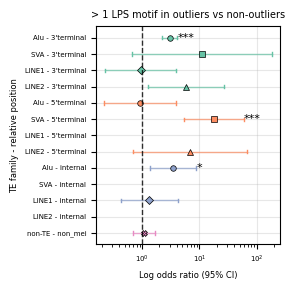

In [26]:
# copied over from outlier followup -- this is conditioning on outliers and variable status shows that Alus are enriched while other groups are not when considering just variable regions
# Initialize a dictionary to store the results
major_families = ['Alu', 'SVA', 'LINE1', 'LINE2', 'non-TE']
conditional_enrichment_values = {}
LPS['mei_family_plot'] = LPS['mei_family'].replace({'SINE_Alu':'Alu', 'Retroposon_SVA':'SVA', 'LINE_L1':'LINE1', 'LINE_L2':'LINE2', 'non_mei':'non-TE'})
outliers["mei_family_plot"] =  outliers['mei_family'].replace({'SINE_Alu':'Alu', 'Retroposon_SVA':'SVA', 'LINE_L1':'LINE1', 'LINE_L2':'LINE2', 'non_mei':'non-TE'})
LPS["variable"] = LPS.unique_lps > 1
outliers["variable"] = outliers.unique_lps > 1
LPS["multiple_motifs"] = LPS.num_total_lps_motifs > 1
outliers["multiple_motifs"] = outliers.num_total_lps_motifs > 1
# only include major families and non-MEI in the analysis
# Iterate over unique combinations of mei_family_plot and terminal_position
for mei_family in major_families:
    for terminal_pos in LPS['terminal_label'].unique():
        # Skip invalid combinations based on the conditions
        if mei_family == "non-TE" and terminal_pos != "non_mei":
            continue
        elif mei_family != "non-TE" and terminal_pos == "non_mei":
            continue
        
        #subset the data for the current combination of mei_family and terminal_pos
        subset_outliers = outliers[(outliers['mei_family_plot'] == mei_family) & (outliers['terminal_label'] == terminal_pos)]
        subset_LPS = LPS[(LPS['mei_family_plot'] == mei_family) & (LPS['terminal_label'] == terminal_pos) & (LPS['str_period'] > 2) & (LPS['variable'])]

        # Calculate odds ratios, p-values, and confidence intervals
        odds_ratio, p_value, ci_lower, ci_upper = calculate_odds_ratio_for_columns(
            {'multiple_motifs':True}, subset_outliers, subset_LPS
        )
        
        # Save the results in the dictionary
        conditional_enrichment_values[(mei_family, terminal_pos)] = (odds_ratio, p_value, ci_lower, ci_upper)

# Print the results
for (mei_family, terminal_pos), (odds_ratio, p_value, ci_lower, ci_upper) in conditional_enrichment_values.items():
    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    print(f"MEI Family: {mei_family}, Terminal Position: {terminal_pos} => OR: {odds_ratio:.3f}, CI: ({ci_lower:.3f}, {ci_upper:.3f}), p-value: {p_value:.3e} {significance}")

# plot a forest plot for all of the results above, with different colors for each mei_family_plot and terminal_label combination, and include confidence intervals and p-values in the plot, don't include the nan group in the plot
# Prepare data for plotting
sample_odds_ratios = []
sample_ci_lowers = []
sample_ci_uppers = []
sample_labels = []
sample_colors = []
sample_significance = []
# plot each terminal_label in a different color and use different markers for each mei_family_plot
label_colors = {
    "3'terminal": plt.get_cmap('Set2')(0),
    "5'terminal": plt.get_cmap('Set2')(1),
    "internal": plt.get_cmap('Set2')(2),
    "non_mei": plt.get_cmap('Set2')(3)
}
marker_styles = {
    "Alu": 'o',
    "SVA": 's',
    "LINE1": 'D',
    "LINE2": '^',
    "non-TE": 'X'
}
for (mei_family, terminal_pos), (odds_ratio, p_value, ci_lower, ci_upper) in conditional_enrichment_values.items():
    if pd.isna(mei_family) or pd.isna(terminal_pos):
        continue
    sample_odds_ratios.append(odds_ratio)
    sample_ci_lowers.append(ci_lower)
    sample_ci_uppers.append(ci_upper)
    sample_labels.append(f"{mei_family} - {terminal_pos}")
    sample_colors.append(label_colors.get(terminal_pos, "gray"))
    sample_significance.append("***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "")

fig, ax = plt.subplots(figsize=(3, 3))

sorted_indices = sorted(range(len(sample_labels)), key=lambda i: sample_labels[i].split(" - ")[1])
sample_odds_ratios = [sample_odds_ratios[i] for i in sorted_indices]
sample_ci_lowers = [sample_ci_lowers[i] for i in sorted_indices]
sample_ci_uppers = [sample_ci_uppers[i] for i in sorted_indices]
sample_labels = [sample_labels[i] for i in sorted_indices]
sample_colors = [sample_colors[i] for i in sorted_indices]
sample_significance = [sample_significance[i] for i in sorted_indices]

y_positions = np.arange(len(sample_labels))[::-1]

for i, (y, or_val, ci_low, ci_up, color, label) in enumerate(
    zip(y_positions, sample_odds_ratios, sample_ci_lowers, sample_ci_uppers,
        sample_colors, sample_labels)
):
    if ci_up != float("inf"):
        ax.plot([ci_low, ci_up], [y, y], "-", color=color, linewidth=1, alpha=0.7)

    marker = marker_styles.get(label.split(" - ")[0], "o")
    ax.plot(or_val, y, marker, markersize=4, color=color,
            markeredgecolor="black", markeredgewidth=0.5)

    cap_size = 0.1
    ax.plot([ci_low, ci_low], [y - cap_size, y + cap_size], "-", color=color, linewidth=1)
    ax.plot([ci_up, ci_up], [y - cap_size, y + cap_size], "-", color=color, linewidth=1)
    ax.text(ci_up + 0.1, y, sample_significance[i], color="black",
            fontsize=8, verticalalignment="center")

ax.axvline(x=1, color="black", linestyle="--", linewidth=1, alpha=0.8)
ax.set_yticks(y_positions)
ax.set_yticklabels(sample_labels, fontsize=tick_size)
ax.set_xlabel("Log odds ratio (95% CI)", fontsize=label_size)
ax.set_ylabel("TE family - relative position", fontsize=label_size)
ax.tick_params(axis="x", labelsize=tick_size)
ax.set_xscale("log")
ax.set_title("> 1 LPS motif in outliers vs non-outliers", fontsize=title_size)
ax.grid(True, axis="both", alpha=0.3)

plt.tight_layout()
# save
plt.savefig(plot_dir + "/suppfig_7_multi_motif_outliers_vs_nonoutliers.pdf", dpi=300)
plt.show()
